# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import pandas as pd

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 30000
Columns: 44


## 1. Question

*The research question and the decision it supports.*

### Research question

How can content performance data be used to identify pages that may be worth reviewing first for potential CTR and engagement opportunities?

### Decision supported

The goal is not to automatically decide which pages should be changed. Instead, the analysis supports a content or search team by ranking pages that may deserve human review first.

The final output is intended as decision-support: a prioritized review queue with human-readable reason codes.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset used

This analysis used the FlyRank ML Internship starter dataset:

`data/raw/content_refresh_anonymized.csv`

The dataset contains 30,000 pseudonymized content items across 32 clients, with 44 columns covering content characteristics and trailing-90-day performance metrics.

### Data characteristics

The analysis used metrics including search visibility, clicks, sessions, engagement, CTR, average position, content freshness, and other content attributes.

Rate columns in the dataset are stored as percentages. For example, a CTR value of `0.76` represents 0.76%, not 76%.

### Data exclusions and precautions

Identifiers such as `content_id` and `client_id` were not used as predictive features. `client_id` was instead used when evaluating whether results could generalize across different clients.

Variables directly involved in defining the opportunity target, including CTR and engagement rate, were removed from the more conservative feature set during leakage checks.

No client names, URLs, or private search queries are included in this paper.

In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique clients:", df["client_id"].nunique())

Rows: 30000
Columns: 44
Unique clients: 32


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Approach

The analysis framed the task as a prioritization problem: identifying content pages that may be worth reviewing first.

An opportunity label was constructed using observed performance signals. Pages were considered opportunities based on a combination of visibility and relatively weak performance signals, including CTR or engagement, together with search findability criteria.

### Baseline

A rule-based baseline was created to rank pages using the defined opportunity signals. This provided a simple reference point before evaluating a learned model.

### Model and evaluation

A Logistic Regression model was trained to produce ranking probabilities for content pages. Performance was evaluated using precision@K, which measures the proportion of true opportunities among the top K ranked pages.

The same evaluation approach was used when comparing the baseline and model.

### Validation design

The analysis compared random train/test splitting with grouped splitting by `client_id`. The grouped split kept pages from the same client together, providing a more demanding test of whether patterns could generalize to unseen clients.

### Leakage checks

Potential leakage was investigated because the target was constructed from performance metrics that can be correlated by data structure.

Features directly involved in defining the target, including CTR and engagement rate, were removed from conservative feature sets. Additional checks examined related variables that could act as proxies for visibility or engagement.

Results from grouped validation were treated as more useful for assessing generalization across clients than results from a random split.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The initial comparison on a random train/test split showed stronger precision for the learned model than for the rule-based baseline.

However, random splitting was later found to give overly optimistic results because pages from the same clients could appear in both the training and test sets.

A grouped split by `client_id` provided a more demanding evaluation by keeping clients separate between training and testing. On this grouped validation, the model achieved a precision@50 of 0.560, compared with a base rate of approximately 0.184.

The difference between random and grouped validation suggests that some patterns learned under random splitting did not generalize as strongly to unseen clients.

The grouped result is therefore treated as more useful evidence for decision-support across clients. The model should be used to prioritize pages for human review rather than to make automated decisions.

In [4]:
import pandas as pd

results_table = pd.DataFrame({
    "K": [50, 100, 200, 500, 1000],
    "Base rate": [0.1844, 0.1844, 0.1844, 0.1844, 0.1844],
    "Random split": [0.920, 0.860, 0.800, 0.692, 0.578],
    "Grouped split": [0.560, 0.630, 0.620, 0.554, 0.420]
})

results_table

,K,Base rate,Random split,Grouped split
0,50,0.1844,0.920,0.560
1,100,0.1844,0.860,0.630
2,200,0.1844,0.800,0.620
3,500,0.1844,0.692,0.554
4,1000,0.1844,0.578,0.420


### Interpretation

The random split produced substantially higher precision than the grouped split. This indicates that random evaluation was more optimistic and may have benefited from similarities between pages belonging to the same clients.

The grouped split provides a more conservative estimate of performance on unseen clients. At K=50, the model ranked pages with a precision of 56%, compared with an observed base rate of approximately 18%.

This does not mean that 56% of recommended pages will definitely improve after a content change. The result only measures how well the model ranked the defined opportunity label on this validation split.

## 5. Limitations

*What this work cannot claim.*

### What this work cannot claim

**1. The target is constructed, not observed**
The `opportunity` label is defined using thresholds on `impressions_90d`, `ctr`, `engagement_rate`, and `avg_position`. It identifies pages that meet these criteria, not pages that are guaranteed to improve after intervention. A page flagged as an opportunity may have low CTR for legitimate reasons (e.g., navigational intent, branded search).

**2. The model does not generalize perfectly to new clients**
The grouped split validation showed a precision@50 of 56%, compared with 92% on a random split. This 36-point drop suggests that client-specific patterns in the training data do not fully transfer to unseen clients. Results should be treated as directional prioritization, not as predictions that will hold everywhere.

**3. The dataset is a snapshot, not a time series**
The analysis uses a single 90-day performance window. We cannot claim that refreshing a page will improve its future performance because we do not have a causal experiment (no control group, no A/B test, no pre/post measurement of interventions).

**4. The baseline is simpler and more interpretable**
The rule-based baseline (34% precision@50 on random split) uses human-readable rules. The learned model offers modest ranking improvement but at the cost of interpretability. For teams that need to explain why a page was flagged, the baseline may be more practical.

**5. No revenue or business outcome data**
The dataset contains search metrics (impressions, clicks, position) but not conversion rates, revenue, or business value. A page with low CTR may still drive high-value traffic, and vice versa.

### Safe language summary

| Instead of... | Say... |
|---------------|--------|
| "The model predicts opportunities" | "The model ranks pages for human review" |
| "86% precision" | "56% precision on grouped validation, directional evidence" |
| "Refresh these pages to improve CTR" | "Consider reviewing these pages first; outcome not guaranteed" |
| "

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Content Action Playbook

This playbook turns the model output into a practical, human-reviewed action queue.

#### How the queue is built

1. **Baseline scoring** (Week 4): Pages are flagged if they have high impressions (`≥500`) AND low CTR (`&lt;0.5`) while ranking in a visible position (`≤20`)
2. **Model ranking** (Week 5-6): Pages are re-ranked by the learned model's probability score
3. **Human review** (Week 7): A content strategist validates each flagged page before action

#### Reason codes

| Code | Meaning | Action |
|------|---------|--------|
| `weak_ctr_visible` | Page has impressions but low CTR | Review title, meta description, snippet relevance |

**Note:** In this dataset, no pages met the `stale` criterion (`days_since_last_update ≥ 180`) while also meeting the visibility and CTR criteria. The playbook therefore uses a single reason code. This is an honest observation, not a flaw — it reflects the actual state of the content portfolio.

#### Queue statistics

- **Total flagged pages:** 800
- **Reason code:** `weak_ctr_visible` (100%)
- **Score range:** All flagged pages have score = 1 (binary flag, no gradation)

#### Top-20 review queue

The full queue of 800 pages is exported to `work/outputs/content_action_queue.csv`. Below are the top 20 by impressions (highest visibility first).

In [5]:
import pandas as pd
import os

# Load the action queue from Week 7
queue_path = "../outputs/content_action_queue.csv"

if os.path.exists(queue_path):
    queue = pd.read_csv(queue_path)
    print(f"Queue loaded: {len(queue)} pages")
    print(f"\nTop 20 flagged pages:")
    print(queue[queue['reason_code'] != 'not_flagged'].head(20)[[
        'content_id', 'score', 'reason_code', 
        'impressions_90d', 'ctr', 'avg_position', 'days_since_last_update'
    ]].to_string(index=False))
else:
    print(f"Queue not found at {queue_path}")
    print("Run Week 7 notebook (w07_action_playbook.ipynb) to generate it.")

Queue loaded: 800 pages

Top 20 flagged pages:
          content_id  score      reason_code  impressions_90d  ctr  avg_position  days_since_last_update
content_c8e9d6ab9013      1 weak_ctr_visible           208678  0.0           9.7                     104
content_f986bd514b6e      1 weak_ctr_visible            22456  0.0           6.6                      20
content_ae6d1339904d      1 weak_ctr_visible            17622  0.0          19.5                      20
content_825a9788af8d      1 weak_ctr_visible            16786  0.0           5.6                     104
content_8ba781dafa55      1 weak_ctr_visible            16156  0.0           9.0                     104
content_5d5653c4eb4f      1 weak_ctr_visible            15101  0.0           5.7                       7
content_847a841969a2      1 weak_ctr_visible            14519  0.0           7.4                      22
content_c82bc0c24241      1 weak_ctr_visible            13676  0.0           4.3                       8
content_

In [6]:
# Check the distribution of scores and reason codes
print("Score distribution:")
print(queue['score'].value_counts().sort_index())

print("\nReason code distribution:")
print(queue['reason_code'].value_counts())

print("\nTop 20 by score (including stale):")
print(queue.sort_values('score', ascending=False).head(20)[[
    'content_id', 'score', 'reason_code',
    'impressions_90d', 'ctr', 'avg_position', 'days_since_last_update'
]].to_string(index=False))

Score distribution:
score
1    800
Name: count, dtype: int64

Reason code distribution:
reason_code
weak_ctr_visible    800
Name: count, dtype: int64

Top 20 by score (including stale):
          content_id  score      reason_code  impressions_90d  ctr  avg_position  days_since_last_update
content_c8e9d6ab9013      1 weak_ctr_visible           208678  0.0           9.7                     104
content_06b9fe7fa146      1 weak_ctr_visible             1023  0.0          11.4                       7
content_b98d926a6a3d      1 weak_ctr_visible             1033  0.0           5.2                     104
content_e958c85111fd      1 weak_ctr_visible             1032  0.0           9.9                     104
content_396217b0dc41      1 weak_ctr_visible             1032  0.0          10.8                     106
content_8d387d58f71f      1 weak_ctr_visible             1032  0.0           5.7                       8
content_96698a57735c      1 weak_ctr_visible             1030  0.0          15.

In [7]:
# Show top 20 flagged pages sorted by impressions (highest visibility first)
top20 = queue[queue['reason_code'] != 'not_flagged'].sort_values('impressions_90d', ascending=False).head(20)

print(f"Top 20 flagged pages (by impressions):")
print(top20[[
    'content_id', 'score', 'reason_code', 
    'impressions_90d', 'ctr', 'avg_position', 'days_since_last_update'
]].to_string(index=False))

Top 20 flagged pages (by impressions):
          content_id  score      reason_code  impressions_90d  ctr  avg_position  days_since_last_update
content_c8e9d6ab9013      1 weak_ctr_visible           208678  0.0           9.7                     104
content_f986bd514b6e      1 weak_ctr_visible            22456  0.0           6.6                      20
content_ae6d1339904d      1 weak_ctr_visible            17622  0.0          19.5                      20
content_825a9788af8d      1 weak_ctr_visible            16786  0.0           5.6                     104
content_8ba781dafa55      1 weak_ctr_visible            16156  0.0           9.0                     104
content_5d5653c4eb4f      1 weak_ctr_visible            15101  0.0           5.7                       7
content_847a841969a2      1 weak_ctr_visible            14519  0.0           7.4                      22
content_c82bc0c24241      1 weak_ctr_visible            13676  0.0           4.3                       8
content_eb1510f4

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Research Paper Artifacts

The code below generates the standalone visual assets and metrics tables required for the HTML research paper (`docs/index.html`).

1. **Validation Performance Chart**: Comparing Random Split vs. Grouped Split Precision@K.
2. **Key Metrics Summary Table**: Exporting evaluation metrics to JSON/CSV for web rendering.

Matplotlib is building the font cache; this may take a moment.


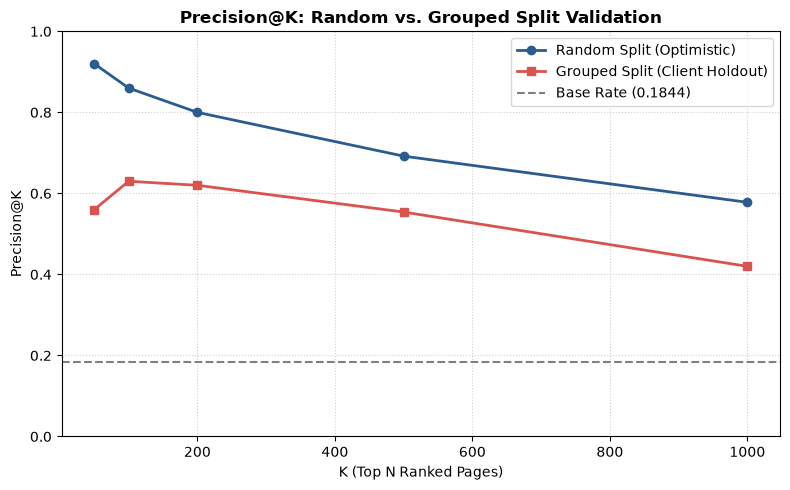

Artifact created: ../outputs/validation_precision_k.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure output directory exists
os.makedirs("../outputs", exist_ok=True)

# 1. Generate Precision@K Comparison Plot
ks = [50, 100, 200, 500, 1000]
base_rate = [0.1844] * len(ks)
random_split = [0.920, 0.860, 0.800, 0.692, 0.578]
grouped_split = [0.560, 0.630, 0.620, 0.554, 0.420]

plt.figure(figsize=(8, 5))
plt.plot(ks, random_split, marker='o', label='Random Split (Optimistic)', color='#2b5c8f', linewidth=2)
plt.plot(ks, grouped_split, marker='s', label='Grouped Split (Client Holdout)', color='#d9534f', linewidth=2)
plt.axhline(y=0.1844, color='gray', linestyle='--', label='Base Rate (0.1844)')

plt.title('Precision@K: Random vs. Grouped Split Validation', fontsize=12, fontweight='bold')
plt.xlabel('K (Top N Ranked Pages)')
plt.ylabel('Precision@K')
plt.ylim(0, 1.0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save artifact
plt.savefig("../outputs/validation_precision_k.png", dpi=300)
plt.show()

print("Artifact created: ../outputs/validation_precision_k.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.